In [1]:
import pandas as pd
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding,Dense,LSTM
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dropout
import nltk
import re
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from  nltk.corpus import stopwords 
from nltk.stem.porter import PorterStemmer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import mlflow
from mlflow.models.signature import infer_signature
from mlflow.tracking import MlflowClient
import joblib

2025-07-27 22:43:54.184463: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-27 22:43:54.185650: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-27 22:43:54.189092: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-27 22:43:54.197740: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753652634.214895  188228 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753652634.21

In [2]:
df=pd.read_csv("fake_news_net.csv")
df.head()

,title,news_url,source_domain,tweet_num,real
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1


In [3]:
df=df.dropna()

In [4]:
x=df.drop('real',axis=1)

In [5]:
y=df['real']

In [6]:
x.shape

(22866, 4)

In [7]:
y.shape

(22866,)

In [8]:
voc_size=5000

In [9]:
messages=x.copy()

In [10]:
messages['title'][1]

"People's Choice Awards 2018: The best red carpet looks"

In [11]:
messages.reset_index(inplace=True,drop=True)

In [12]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/cloud/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
ps=PorterStemmer()
corpus=[]
for i in range(0,len(messages)):
    review = re.sub('[^a-zA-Z]', ' ', messages['title'][i])
    review = review.lower()
    review = review.split()
    review = [ps.stem(word) for word in review if not word in stopwords.words('english')]
    review = ' '.join(review)
    corpus.append(review)        

In [14]:
corpus

['kandi burruss explod rape accus real housew atlanta reunion video',
 'peopl choic award best red carpet look',
 'sophia bush send sweet birthday messag one tree hill co star hilari burton breyton eva',
 'colombian singer maluma spark rumour inappropri relationship aunt',
 'gossip girl year later upper east sider shock world chang pop cultur forev',
 'gwen stefani got dump blake shelton jealousi drama exclus',
 'broward counti sheriff fire lie parkland',
 'amber rose shut french montana date rumor call rapper bruvaaa',
 'mindi kale make first post babi appear disneyland wrinkl time co star',
 'katharin mcphee butcher toni nomin drink',
 'wag miami star ashley nicol robert philip wheeler marri',
 'mel gibson hollywood pedophil nowher left hide',
 'medium tyler henri address chill messag kristin cavallari deceas brother express read',
 'dwt season result week disney night',
 'reason tarek el moussa overcom latest back injuri',
 'david cassidi cut estrang daughter kati complet leav son b

In [15]:
one_hot_repr=[one_hot(words,voc_size)for words in corpus] 
one_hot_repr

[[4184, 4436, 1275, 420, 850, 1672, 1281, 1430, 412, 3473],
 [176, 2737, 2839, 1481, 4090, 1378, 3975],
 [4710,
  1968,
  1492,
  3789,
  4955,
  2477,
  2581,
  4504,
  4876,
  4162,
  232,
  887,
  3187,
  2969,
  3162],
 [10, 3478, 2884, 2977, 4912, 3474, 4908, 1173],
 [2427, 3616, 4603, 1868, 2623, 4113, 1401, 2714, 153, 4879, 347, 4550, 4768],
 [3255, 3181, 1360, 2721, 3412, 624, 1824, 2785, 3386],
 [428, 1997, 4783, 4322, 1730, 2708],
 [382, 2071, 2874, 3746, 1497, 773, 759, 1725, 1291, 2622],
 [3347, 2709, 4351, 2036, 3668, 4305, 1965, 1221, 3155, 2380, 4162, 232],
 [3374, 1629, 445, 2659, 2857, 2302],
 [1611, 1449, 232, 4169, 653, 904, 698, 4321, 3956],
 [2780, 3783, 273, 4171, 4477, 1620, 3663],
 [939, 4054, 4134, 3115, 3454, 2477, 3100, 4635, 1528, 1886, 4511, 4089],
 [3557, 1326, 1264, 4216, 3981, 1543],
 [3685, 1640, 1507, 3547, 2296, 3447, 3476, 4287],
 [890, 1466, 3612, 4142, 4737, 2921, 1395, 873, 2797, 2903],
 [3664, 3384, 3533, 2979, 2187, 3917, 3300],
 [1477, 3606, 13

In [16]:
sent_length=20
embedded_docs=pad_sequences(one_hot_repr,padding='pre',maxlen=sent_length)
embedded_docs

array([[   0,    0,    0, ..., 1430,  412, 3473],
       [   0,    0,    0, ..., 4090, 1378, 3975],
       [   0,    0,    0, ..., 3187, 2969, 3162],
       ...,
       [   0,    0,    0, ..., 4589, 3137, 2842],
       [   0,    0,    0, ..., 2316,  667, 3386],
       [   0,    0,    0, ..., 4471, 3588, 2839]], dtype=int32)

In [17]:
embedded_docs[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0, 4184,
       4436, 1275,  420,  850, 1672, 1281, 1430,  412, 3473], dtype=int32)

In [18]:
embedding_vector_features=40
model=Sequential()
model.add(Embedding(voc_size,embedding_vector_features,input_length=sent_length))
model.add(LSTM(100))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
print(model.summary())

/home/cloud/anaconda3/envs/work/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
E0000 00:00:1753652651.670609  188228 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1753652651.674189  188228 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [19]:
len(embedded_docs),y.shape

(22866, (22866,))

In [20]:
X_final=np.array(embedded_docs)
y_final=np.array(y)

In [21]:
X_final.shape,y_final.shape

((22866, 20), (22866,))

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.33, random_state=42)

In [23]:
model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=10,batch_size=64)

Epoch 1/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.7706 - loss: 0.5367 - val_accuracy: 0.8292 - val_loss: 0.4060
Epoch 2/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8484 - loss: 0.3467 - val_accuracy: 0.8277 - val_loss: 0.4087
Epoch 3/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8703 - loss: 0.3020 - val_accuracy: 0.8255 - val_loss: 0.4163
Epoch 4/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8817 - loss: 0.2774 - val_accuracy: 0.8184 - val_loss: 0.4347
Epoch 5/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8908 - loss: 0.2538 - val_accuracy: 0.8126 - val_loss: 0.4514
Epoch 6/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9069 - loss: 0.2285 - val_accuracy: 0.8012 - val_loss: 0.5124
Epoch 7/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9183 - loss: 0.2046 - val_accuracy: 0.7996 - val_loss: 0.5178
Epoch 8/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9271 - loss: 0.1781 - val_accu

In [24]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("fake_news_classifier_using_lstm1")


with mlflow.start_run() as run:

    mlflow.log_artifact("input_dataset.csv")

    mlflow.log_params({
        "vocabulary_size_embending": voc_size,
        "input_embending": embedding_vector_features,
        "input_length_embending": sent_length,
        "unit_number": 100,
        "number_neuron_by_layer": 1,
        "number of layer": 1,
        "activation": "sigmoid",
        "epoch": 10,
        "batch_size": 64
    })

    signature = infer_signature(model_input=X_train, model_output=model.predict(X_test))
    mlflow.keras.log_model(model, name="model", signature=signature)

    run_id = run.info.run_id

    result = mlflow.register_model(
        model_uri=f"runs:/{run_id}/model",
        name="fake_news_classifier_using_lstm"
    )

    client = MlflowClient()
    client.transition_model_version_stage(
        name="fake_news_classifier_using_lstm",
        version=result.version,
        stage="Staging"
    )


236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


Registered model 'fake_news_classifier_using_lstm' already exists. Creating a new version of this model...
2025/07/27 22:45:15 WARNING mlflow.tracking._model_registry.fluent: Run with id de7a79b8ffc04b458d2882820d8d9362 has no artifacts at artifact path 'model', registering model based on models:/m-cc7171f0dfaf4e6f92251eb38734b956 instead
2025/07/27 22:45:15 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: fake_news_classifier_using_lstm, version 2


🏃 View run brawny-whale-79 at: http://localhost:5000/#/experiments/406984132000260827/runs/de7a79b8ffc04b458d2882820d8d9362
🧪 View experiment at: http://localhost:5000/#/experiments/406984132000260827


Created version '2' of model 'fake_news_classifier_using_lstm'.
/tmp/ipykernel_188228/393768375.py:32: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


In [25]:
embedding_vector_features=40
model=Sequential()
model.add(Embedding(voc_size,embedding_vector_features,input_length=sent_length))
model.add(Dropout(0.3))
model.add(LSTM(100))
model.add(Dropout(0.3))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model.summary()

/home/cloud/anaconda3/envs/work/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
y_prob=model.predict(X_test)
y_prob

236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


array([[0.49786654],
       [0.4979237 ],
       [0.50290984],
       ...,
       [0.50113475],
       [0.49631718],
       [0.4966966 ]], dtype=float32)

In [27]:
y_pred = np.argmax(y_prob, axis=1)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [28]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[1842,    0],
       [5704,    0]])

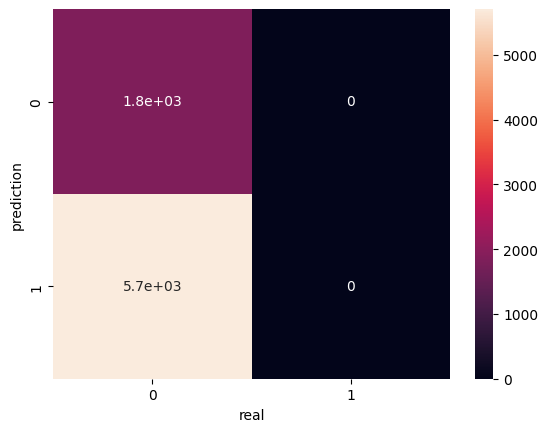

In [29]:
sns.heatmap(cm,annot=True)
plt.xlabel("real")
plt.ylabel("prediction")
plt.show()

In [30]:
accuracy_score(y_test,y_pred)

0.24410283593957063

In [31]:
joblib.dump(model,"model.pk")

['model.pk']